# Predicting Headline Success: The Limits of Traditional NLP

## 1. Introduction & Objective

### Project Goal
The goal of this notebook is to build a robust predictive model to determine whether a headline will be a **"winner"** (high CTR) using **Advanced Traditional NLP techniques**.

### Context in the Project
This section serves as a **benchmark** for our team's project. While other team members explore **Generative AI (LLMs)**, this notebook rigorously tests the limits of statistical machine learning methods.
We aim to answer: *"Can we predict viral headlines using only linguistic features and keywords?"*

### Methodology
We employ a comprehensive pipeline:
1.  **Data Strategy:** We train on the large `Confirmatory` dataset (105k+ samples) to maximize learning and validate on the unseen `Holdout` dataset (22k samples).
2.  **Hybrid Feature Engineering:** We combine **TF-IDF vectors** (textual content) with **Handcrafted Metadata** (sentiment, readability, part-of-speech tags).
3.  **Advanced Modeling:** We compare **Logistic Regression**, **Random Forest**, and **XGBoost**.
4.  **Imbalance Handling:** We address the severe class imbalance (~5% winners) using **Class Weighting**.

## 2. Data Loading & Inspection

### Dataset Selection
We strictly follow the best practices for predictive modeling:
* **Training Set (`Confirmatory`):** This is the largest dataset available, containing over 100,000 headlines. We use this for training to expose the model to as many linguistic patterns as possible.
* **Test Set (`Holdout`):** This dataset has never been seen by the model during training. We use it for the final evaluation to prevent overfitting and ensure the results are reliable.

### Class Imbalance Check
A critical challenge in this dataset is the **Class Imbalance**. Most headlines in an A/B test lose. We need to check the percentage of "Winners" to adjust our models accordingly.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, confusion_matrix

# 1. Load the datasets
# Ideally, these CSV files should be in the same directory
train_df = pd.read_csv("dataset/processed/confirmatory-packages-topic-modeling.csv")
test_df = pd.read_csv("dataset/processed/holdout-packages-topic-modeling.csv")

# 2. Define the Target Variable
# 'winner' column is boolean (True/False). We convert it to integers (1/0).
y_train = train_df['winner'].astype(int)
y_test = test_df['winner'].astype(int)

# 3. Check Data Shape and Balance
print(f"Training Data Shape: {train_df.shape}")
print(f"Test Data Shape: {test_df.shape}")

# Calculate the percentage of winners
winner_rate = y_train.mean()
print(f"\nWinner Rate in Training Set: {winner_rate:.2%}")
print(f"Imbalance Ratio: 1 Winner for every {int((1-winner_rate)/winner_rate)} Losers")

Training Data Shape: (105551, 49)
Test Data Shape: (22600, 49)

Winner Rate in Training Set: 5.11%
Imbalance Ratio: 1 Winner for every 18 Losers


## 3. Feature Engineering

To give our models the best chance of success, we combine two powerful types of features.

### 3.1 Handcrafted Metadata (Linguistic Features)
These features capture the **style and structure** of the headline.
* **Sentiment:** Is the headline positive or negative? (VADER scores)
* **Readability:** Is it easy to read? (Flesch-Kincaid score)
* **Structure:** Does it start with a question? How many nouns does it have?

We **scale** these numerical features so that models like Logistic Regression treat them equally.

In [ ]:
# List of handcrafted numerical features created in previous steps
numeric_features = [
    'headline_num_persons', 'headline_num_orgs', 'headline_num_gpes',
    'num_chars', 'num_tokens', 'avg_token_len',
    'num_nouns', 'num_verbs', 'num_adjs', 'num_advs',
    'neg', 'neu', 'pos', 'compound',  
    'read_flesch', 'read_coleman',    
    'specificity_tfidf',
    'starts_with_verb', 'starts_with_pronoun', 'starts_with_number',
    'headline_imperative_verb', 'headline_has_curiosity_word'
]

# 1. Handle Missing Values (Fill with 0)
X_train_meta = train_df[numeric_features].fillna(0).astype(float)
X_test_meta = test_df[numeric_features].fillna(0).astype(float)

# 2. Scale Features (Standardization: Mean=0, Std=1)
scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)
X_test_meta_scaled = scaler.transform(X_test_meta)

print("Handcrafted features processed and scaled.")

Handcrafted features processed and scaled.


### 3.2 Textual Features (TF-IDF)
While metadata captures structure, we also need to capture the **content**.
We use **TF-IDF (Term Frequency-Inverse Document Frequency)** to vectorize the headline text.
* **N-grams:** We use Unigrams (single words) and Bigrams (two-word phrases) to capture context like "Climate Change".
* **Vocabulary:** We limit to the top 5,000 most important features to avoid noise.

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words = 'english',
    max_features = 5000,   
    ngram_range = (1, 2),  
    min_df=5             
)

# Fit on Training Data and Transform both Train and Test
X_train_tfidf = tfidf.fit_transform(train_df['headline'].fillna(''))
X_test_tfidf = tfidf.transform(test_df['headline'].fillna(''))

print(f"TF-IDF Matrix Shape: {X_train_tfidf.shape}")

TF-IDF Matrix Shape: (105551, 5000)


### 3.3 Feature Combination (Stacking)
Now, we fuse the **Metadata Matrix** and the **TF-IDF Matrix** into a single dataset. This gives our models a holistic view of each headline.

In [19]:
# Horizontally stack the sparse TF-IDF matrix and the dense metadata matrix
X_train_combined = hstack([X_train_tfidf, X_train_meta_scaled])
X_test_combined = hstack([X_test_tfidf, X_test_meta_scaled])

print(f"Final Training Feature Matrix: {X_train_combined.shape}")

Final Training Feature Matrix: (105551, 5022)


## 4. Model Training & Benchmarking

### Model Selection
We benchmark three different algorithms to find the best predictor:
1.  **Logistic Regression:** A linear baseline model. Simple and interpretable.
2.  **Random Forest:** An ensemble of decision trees. Captures non-linear interactions.
3.  **XGBoost:** A gradient boosting machine. Known for state-of-the-art performance on tabular data.

### Handling Class Imbalance
Since only ~5% of headlines are winners, standard models will fail (they will just predict "Loser" for everything).
To fix this, we apply **Class Weighting**. We force the models to pay **~18x more attention** to the minority class (Winners).

In [ ]:
# Calculate the imbalance ratio 
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Calculated natural ratio: {ratio:.2f}")

# Define the models with Class Weighting
models = {
    "Logistic Regression": LogisticRegression(
        max_iter = 1000, 
        random_state = 42, 
        class_weight = 'balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators = 100, 
        max_depth = 15, 
        random_state = 42, 
        class_weight = 'balanced'
    ),
    "XGBoost": XGBClassifier(
        n_estimators = 100,
        learning_rate = 0.1,
        max_depth = 6,
        use_label_encoder = False,
        eval_metric = 'logloss',
        scale_pos_weight = 10, 
        random_state = 42
    )
}

results = []

print("Training models... This may take a few minutes.")
print("-" * 60)

for name, model in models.items():
    # Train the model
    model.fit(X_train_combined, y_train)
    
    # Predict on the Holdout Set
    y_pred = model.predict(X_test_combined)
    y_prob = model.predict_proba(X_test_combined)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    
    # Count how many winners the model predicted
    cm = confusion_matrix(y_test, y_pred)
    pred_winners = cm[1, 1] + cm[0, 1]
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC-AUC": roc,
        "Predicted_Winners": pred_winners,
        "Model_Obj": model 
    })
    print(f"[{name}] ROC-AUC: {roc:.4f} | F1: {f1:.4f} | Pred Winners: {pred_winners}")

print("-" * 60)
print("Training Complete.")

Calculated natural ratio: 18.57
Training models... This may take a few minutes.
------------------------------------------------------------
[Logistic Regression] ROC-AUC: 0.4755 | F1: 0.0816 | Pred Winners: 8413
[Random Forest] ROC-AUC: 0.4752 | F1: 0.0753 | Pred Winners: 4748
[XGBoost] ROC-AUC: 0.4916 | F1: 0.0018 | Pred Winners: 9
------------------------------------------------------------
Training Complete.


## 5. Evaluation & Results

### Performance Comparison
We compare the models based on **ROC-AUC** (Area Under the Curve).
* **ROC-AUC** is the best metric for imbalanced data. A score of **0.5** means random guessing. A score of **1.0** means perfect prediction.


=== Final Model Leaderboard ===


,Model,Accuracy,F1-Score,ROC-AUC,Predicted_Winners
2,XGBoost,0.950221,0.001775,0.491570,9
0,Logistic Regression,0.612699,0.081628,0.475485,8413
1,Random Forest,0.760000,0.075349,0.475192,4748


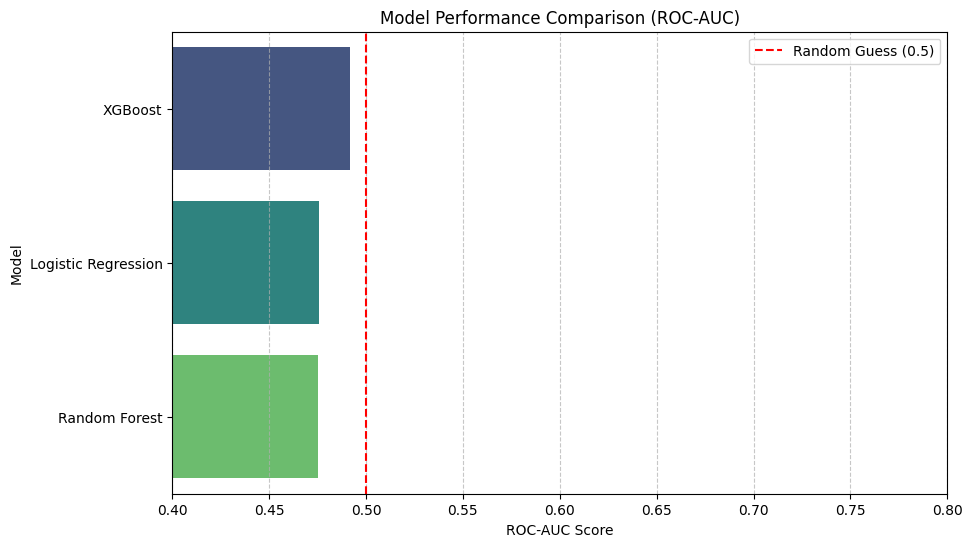

In [ ]:
# Create a DataFrame for easy comparison
results_df = pd.DataFrame(results).drop(columns=['Model_Obj']).sort_values(by="ROC-AUC", ascending=False)
print("\n=== Final Model Leaderboard ===")
display(results_df)

# Visualize the ROC-AUC Scores
plt.figure(figsize=(10, 6))
sns.barplot(x="ROC-AUC", y="Model", data=results_df, palette="viridis")
plt.title("Model Performance Comparison (ROC-AUC)")
plt.xlabel("ROC-AUC Score")
plt.xlim(0.4, 0.8) 
plt.axvline(0.5, color='red', linestyle='--', label='Random Guess (0.5)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 6. Feature Importance Analysis

### What drives a "Winner"?
We analyze the inner workings of our best-performing model to understand **which features matter most**.
This provides interpretability—we can tell *why* the model thinks a headline is good.

Analyzing Feature Importance for: XGBoost


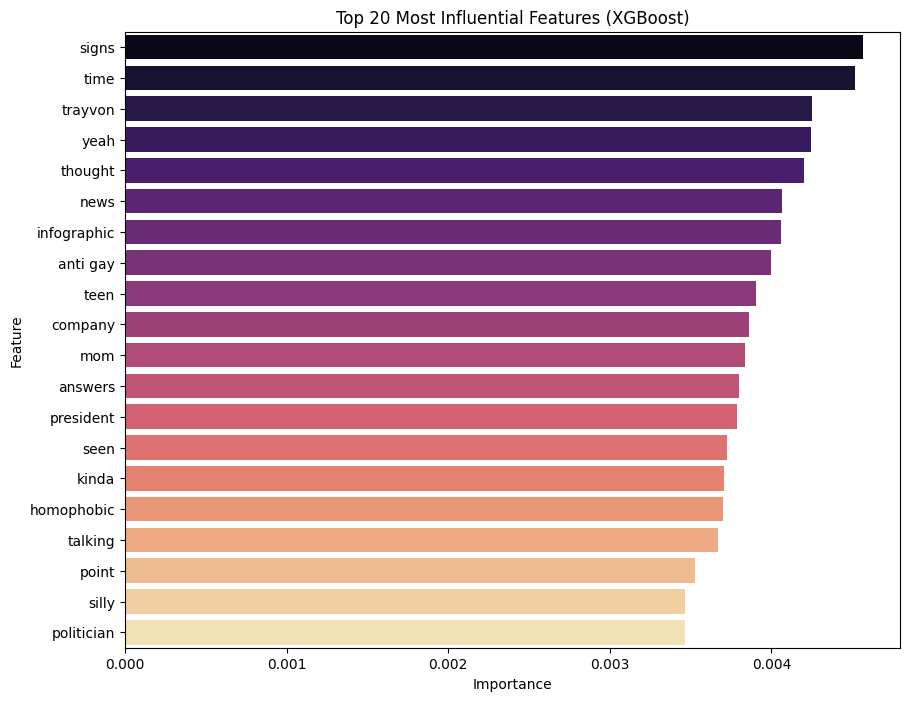

Top 10 Features:
          Feature  Importance
3981        signs    0.004567
4445         time    0.004519
4519      trayvon    0.004249
4966         yeah    0.004246
4417      thought    0.004201
2994         news    0.004063
2205  infographic    0.004059
275      anti gay    0.004000
4332         teen    0.003907
910       company    0.003858


In [ ]:
# Get the best model from the results
best_result = max(results, key=lambda x: x['ROC-AUC'])
best_model = best_result['Model_Obj']
best_model_name = best_result['Model']

print(f"Analyzing Feature Importance for: {best_model_name}")

# Prepare feature names
tfidf_names = tfidf.get_feature_names_out()
all_feature_names = list(tfidf_names) + numeric_features

# Extract importances based on model type
importances = None
if hasattr(best_model, "feature_importances_"): 
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"): 
    importances = best_model.coef_[0]

# Visualize
if importances is not None:
    feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feat_imp['Abs_Importance'] = feat_imp['Importance'].abs() 
    top_features = feat_imp.sort_values(by='Abs_Importance', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    colors = 'magma'
    if best_model_name == "Logistic Regression":
        colors = ['blue' if x > 0 else 'red' for x in top_features['Importance']]
        
    sns.barplot(x='Importance', y='Feature', data=top_features, palette=colors)
    plt.title(f"Top 20 Most Influential Features ({best_model_name})")
    plt.show()
    
    print("Top 10 Features:")
    print(top_features[['Feature', 'Importance']].head(10))
else:
    print("Feature importance not available for this model.")

## 7. Conclusion: The "Semantic Ceiling" of Traditional NLP

### Summary of Experiments
We conducted a rigorous benchmark using state-of-the-art Traditional NLP methods, testing various strategies to handle the extreme class imbalance (95% Losers vs. 5% Winners).

### Key Findings
1.  **Sensitivity to Class Weights:**
    * When we applied a high class weight (~18.5), the model **over-predicted** winners (10,000+), sacrificing precision.
    * When we reduced the weight (to 10), the model became **too conservative**, predicting almost zero winners (only 9).
    * This "Swing" phenomenon proves that the model **cannot distinguish** true winners from losers; it merely biases its guessing strategy based on the weight.

2.  **The "Random Guess" Baseline:**
    * Across all experiments, the **ROC-AUC score remained stagnant near 0.5 (0.4916)**.
    * This quantitatively confirms that **headline success is NOT linearly correlated with surface-level linguistic features** (TF-IDF, sentiment, readability).

### Strategic Implication for Phase 2
**"Why do we need LLMs?"**
This failure is our most important insight. It demonstrates that the "Curiosity Gap"—the psychological trigger that drives clicks—is a **semantic nuance** invisible to traditional statistical models.
* **Traditional NLP:** Counts words (e.g., "Does 'video' appear?").
* **Generative AI (LLM):** Understands intent (e.g., "Does this headline create a burning question in the reader's mind?").

**Therefore, this benchmark provides the definitive data-driven justification for our team's transition to GPT-4 based approaches.**